# Replay

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

CalledProcessError: Command '['git', 'clone', '--depth', '1', '--branch', 'real-video', 'https://@github.com/silvergjeka22/Unified-Lifelong-Action-Learning.git', '/content/ulal']' returned non-zero exit status 128.

In [ ]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [2]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

ModuleNotFoundError: No module named 'src'

In [ ]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

## **Preprocess data**

In [ ]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [ ]:
# BASE
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [ ]:
# TASK 1
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [ ]:
# TASK 2
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [ ]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [ ]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']


### Label encoding

In [ ]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14}


## **Create Loaders**

In [ ]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)

base_train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
base_test_loader  = DataLoader(base_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

In [ ]:
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
model = unfreeze_all(model)

### Expand the head

In [ ]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

### Before training

In [ ]:
snapshots = []
results_baseline = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_baseline)

  base             -> Acc=0.9387  Loss=0.1979
  task1_only        -> Acc=0.0000  Loss=4.4398
  combined_t1       -> Acc=0.6180  Loss=1.6470


In [ ]:
print(f"classifier: in={model.fc.in_features}  out={model.fc.out_features}")

classifier: in=256  out=15


## **Task One**

### Replay buffer

In [ ]:
buffer = ReplayBuffer(max_size=cfg.REPLAY_BUFFER_SIZE)
fill_buffer(buffer, base_train_loader, per_class=15)
print(f"buffer: {len(buffer.data)} clips")

buffer: 150 clips


### Training (replay)

In [ ]:
set_seed(cfg.SEED)
forget_hist = []
track1 = {"Base": base_test_loader, "Task 1": task1_test_loader}
train_task1 = train_continual(model, task1_train_loader, task1_val_loader, device,
                              buffer=buffer, epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                              track_loaders=track1, track_history=forget_hist)

Epoch [1/5] | Train Acc: 0.7787 Loss: 0.8430 | Val Acc: 0.8630 Loss: 0.5378
Epoch [2/5] | Train Acc: 0.9816 Loss: 0.1525 | Val Acc: 0.9041 Loss: 0.3363
Epoch [3/5] | Train Acc: 0.9967 Loss: 0.0612 | Val Acc: 0.9452 Loss: 0.1779
Epoch [4/5] | Train Acc: 0.9967 Loss: 0.0413 | Val Acc: 0.8630 Loss: 0.3046
Epoch [5/5] | Train Acc: 0.9967 Loss: 0.0338 | Val Acc: 0.9041 Loss: 0.3219


### Training curves

<Figure size 640x480 with 0 Axes>

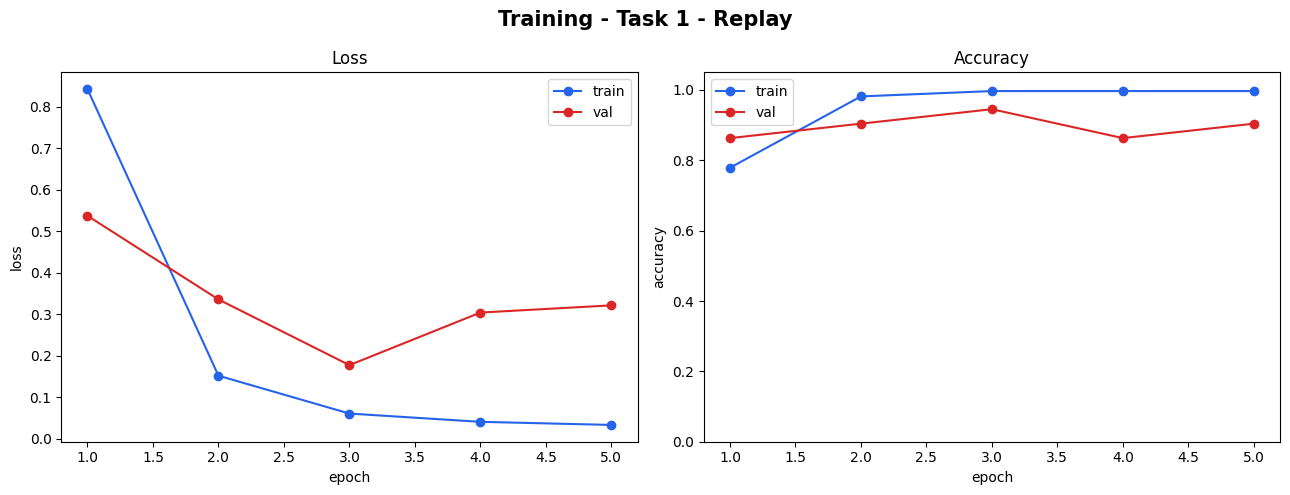

In [ ]:
plot_training_results(train_task1, task_name="Task 1 - Replay")

### Evaluate all tasks

In [ ]:
results_after_t1 = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_after_t1)

  base             -> Acc=0.8962  Loss=0.2708
  task1_only        -> Acc=0.9455  Loss=0.1871
  combined_t1       -> Acc=0.9130  Loss=0.2422


### Confusion matrix

Test Accuracy: 0.9130


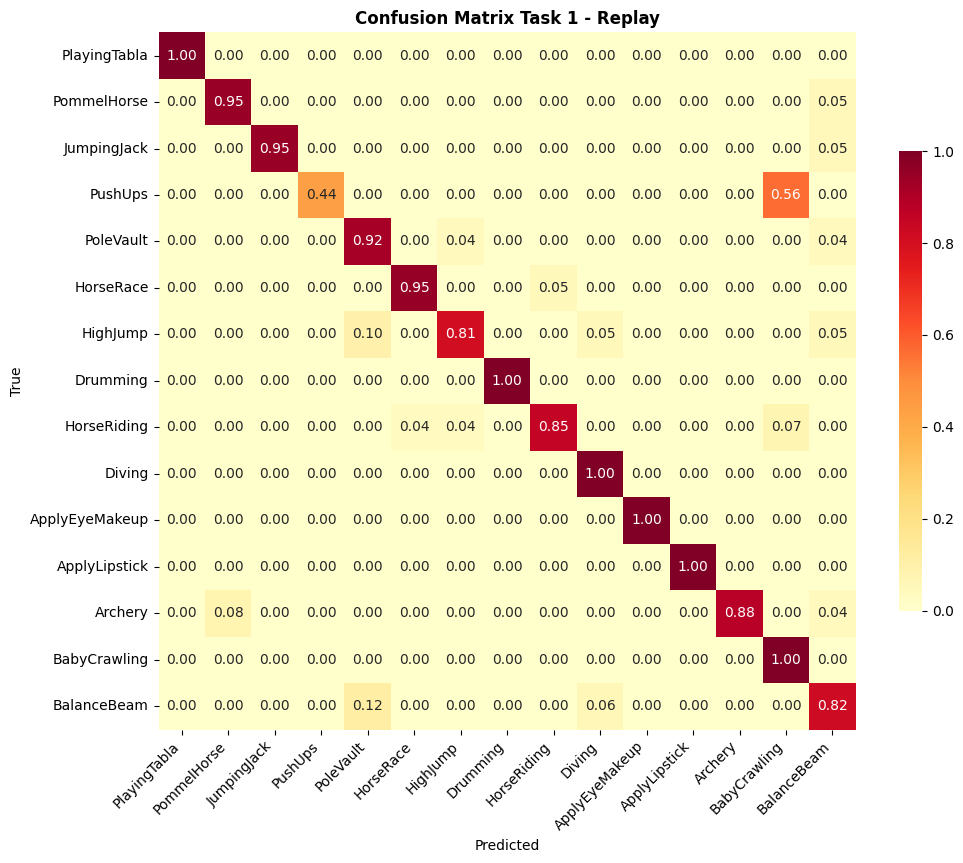

In [ ]:
_, all_preds, all_labels = test_model(model, combined_test_loader, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 1 - Replay")

### Old vs new classes

In [ ]:
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, len(cfg.SELECTED_CLASSES)),
                       split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)))


METRICS FOR 15 CLASSES
  Accuracy : 0.9130
  F1-Score : 0.9109

PER-CLASS REPORT
                precision    recall  f1-score   support

  PlayingTabla       1.00      1.00      1.00        17
   PommelHorse       0.90      0.95      0.92        19
   JumpingJack       1.00      0.95      0.97        19
       PushUps       1.00      0.44      0.61        16
     PoleVault       0.85      0.92      0.88        25
     HorseRace       0.95      0.95      0.95        20
      HighJump       0.89      0.81      0.85        21
      Drumming       1.00      1.00      1.00        25
   HorseRiding       0.96      0.85      0.90        27
        Diving       0.92      1.00      0.96        23
ApplyEyeMakeup       1.00      1.00      1.00        25
 ApplyLipstick       1.00      1.00      1.00        20
       Archery       1.00      0.88      0.94        25
  BabyCrawling       0.68      1.00      0.81        23
   BalanceBeam       0.74      0.82      0.78        17

      accuracy      

## **Task 2**

### Add Task 1 clips to the buffer

In [ ]:
fill_buffer(buffer, task1_train_loader, per_class=15)
print(f"buffer: {len(buffer.data)} clips")

buffer: 225 clips


### Label encoding

In [ ]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


### Loaders

In [ ]:
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test2        = ConcatDataset([base_test, task1_test, task2_test])
combined_test_loader2 = DataLoader(combined_test2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

### Expand the head

In [ ]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

### Before training

In [ ]:
results_baseline_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                         [task1_test_loader, task2_test_loader],
                                         [combined_test_loader, combined_test_loader2])

  base             -> Acc=0.8962  Loss=0.2954
  task1_only        -> Acc=0.9455  Loss=0.2057
  task2_only        -> Acc=0.0000  Loss=4.6555
  combined_t1       -> Acc=0.9130  Loss=0.2647
  combined_t2       -> Acc=0.6697  Loss=1.4349


### Training (replay)

In [ ]:
set_seed(cfg.SEED)
track2 = {"Base": base_test_loader, "Task 1": task1_test_loader, "Task 2": task2_test_loader}
train_task2 = train_continual(model, task2_train_loader, task2_val_loader, device,
                              buffer=buffer, epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                              track_loaders=track2, track_history=forget_hist)

Epoch [1/5] | Train Acc: 0.7604 Loss: 0.9636 | Val Acc: 0.8235 Loss: 0.7833
Epoch [2/5] | Train Acc: 0.9751 Loss: 0.2114 | Val Acc: 0.9882 Loss: 0.2812
Epoch [3/5] | Train Acc: 0.9911 Loss: 0.0851 | Val Acc: 0.9412 Loss: 0.1761
Epoch [4/5] | Train Acc: 1.0000 Loss: 0.0437 | Val Acc: 1.0000 Loss: 0.1252
Epoch [5/5] | Train Acc: 0.9990 Loss: 0.0289 | Val Acc: 0.9647 Loss: 0.1756


### Training curves

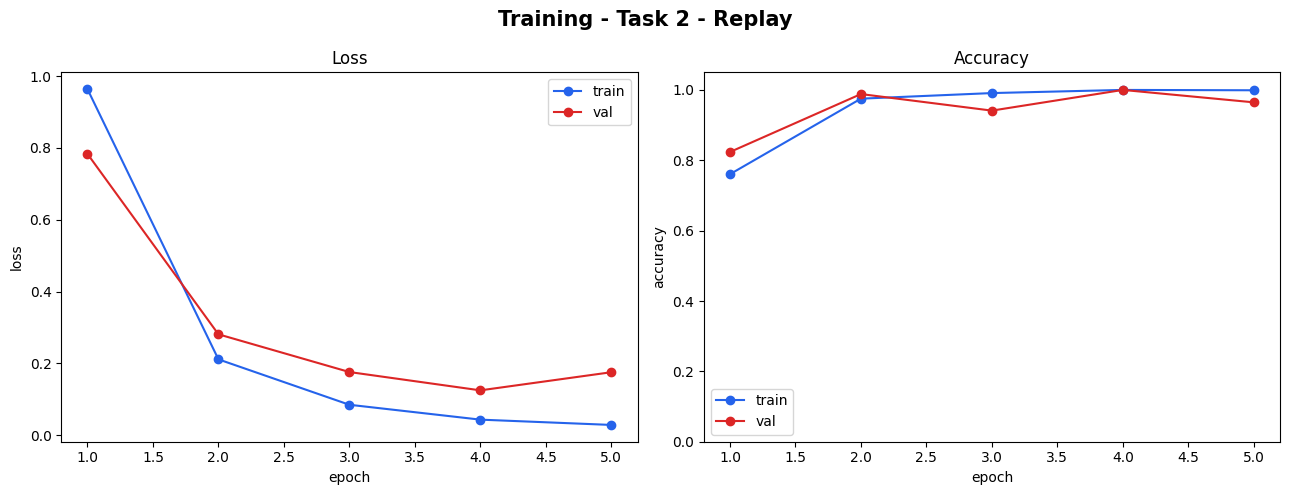

In [ ]:
plot_training_results(train_task2, task_name="Task 2 - Replay")

### Evaluate all tasks

In [ ]:
results_after_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                      [task1_test_loader, task2_test_loader],
                                      [combined_test_loader, combined_test_loader2])
snapshots.append(results_after_t2)

  base             -> Acc=0.8915  Loss=0.3785
  task1_only        -> Acc=0.8182  Loss=0.5342
  task2_only        -> Acc=0.9829  Loss=0.1056
  combined_t1       -> Acc=0.8665  Loss=0.4317
  combined_t2       -> Acc=0.8975  Loss=0.3448


### Confusion matrix

Test Accuracy: 0.8975


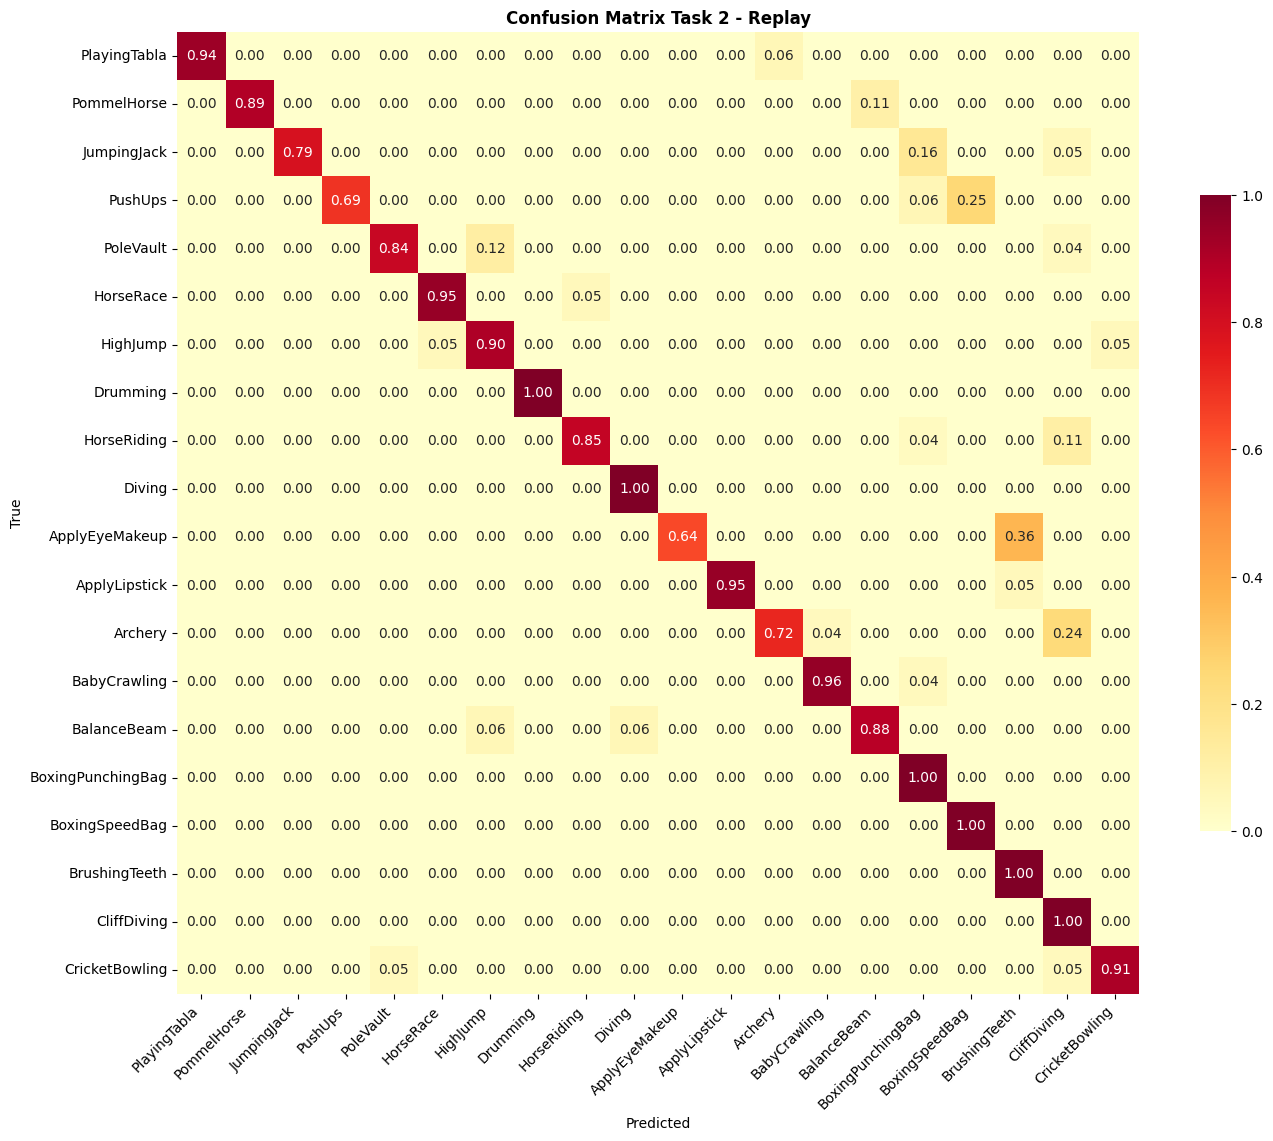

In [ ]:
_, all_preds, all_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 2 - Replay")

### Old vs new classes

In [ ]:
split_new = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_new),
                       split_new=(split_new, len(ALL_CLASSES_LIST)))


METRICS FOR 20 CLASSES
  Accuracy : 0.8975
  F1-Score : 0.8978

PER-CLASS REPORT
                   precision    recall  f1-score   support

     PlayingTabla       1.00      0.94      0.97        17
      PommelHorse       1.00      0.89      0.94        19
      JumpingJack       1.00      0.79      0.88        19
          PushUps       1.00      0.69      0.81        16
        PoleVault       0.95      0.84      0.89        25
        HorseRace       0.95      0.95      0.95        20
         HighJump       0.83      0.90      0.86        21
         Drumming       1.00      1.00      1.00        25
      HorseRiding       0.96      0.85      0.90        27
           Diving       0.96      1.00      0.98        23
   ApplyEyeMakeup       1.00      0.64      0.78        25
    ApplyLipstick       1.00      0.95      0.97        20
          Archery       0.95      0.72      0.82        25
     BabyCrawling       0.96      0.96      0.96        23
      BalanceBeam       0.88    

## **Forgetting**

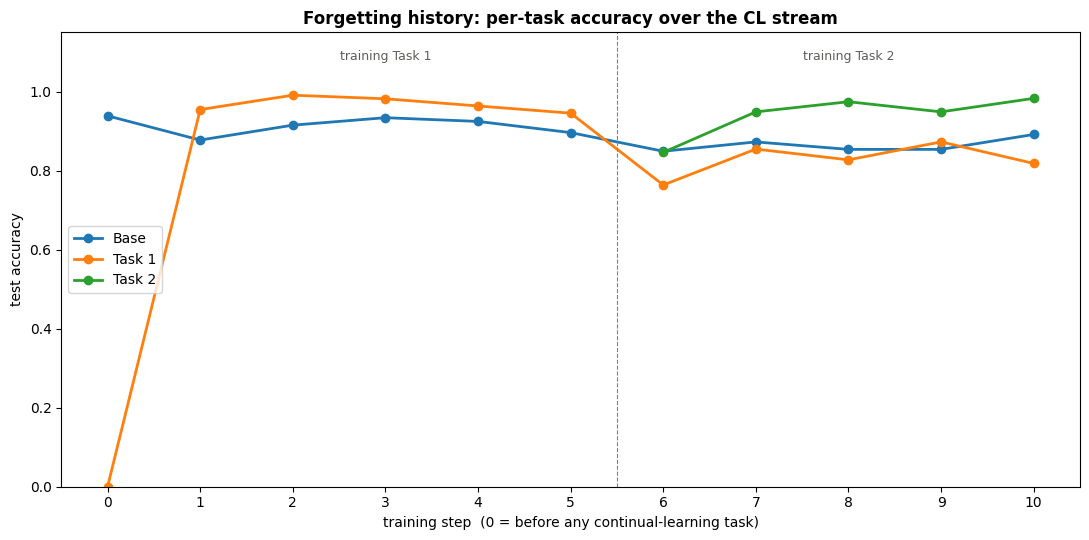

In [ ]:
plot_forgetting_history(forget_hist, epochs_per_task=cfg.CL_EPOCHS)

## **Save**

In [ ]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"arm": "replay", "classes": ALL_CLASSES_LIST, "buffer_clips": len(buffer.data), "snapshots": snapshots}
with open(f"{cfg.RESULTS_DIR}/stage3_replay.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage3_replay.json")

saved -> /content/drive/MyDrive/apai/results/stage3_replay.json


## **Recap**

- A buffer keeps 15 clips of every old class and mixes them into every training batch.
- After Task 2: base 89.2%, Task 1 81.8%, Task 2 98.3%; all 20 classes 89.8%.
- Best continual-learning method: a few stored clips protect the old classes far better than EWC or LwF.